Dataset loaded successfully!
Dataset shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Missing values:
0

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

0 = Genuine transaction
1 = Fraud transaction


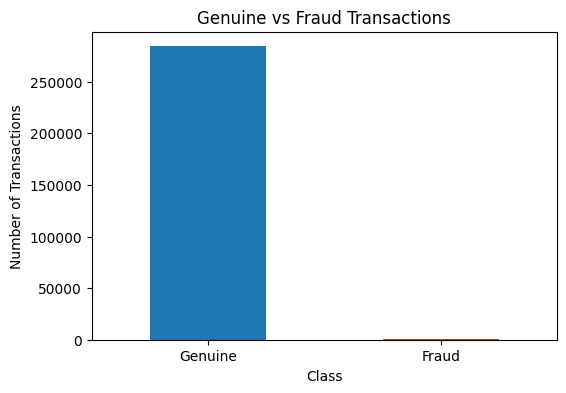


Feature shape: (284807, 30)
Target shape: (284807,)

Training data: (227845, 30)
Testing data: (56962, 30)

Class distribution BEFORE SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

XGBoost model trained successfully!

First 10 predicted fraud probabilities:
[0.00280235 0.00102638 0.01939532 0.00100275 0.0813225  0.00828813
 0.0011686  0.00205459 0.00579819 0.00217661]

THRESHOLD TUNING

Threshold: 0.5
Precision: 0.2699
Recall: 0.898
F1 Score: 0.4151

Threshold: 0.4
Precision: 0.1939
Recall: 0.9082
F1 Score: 0.3196

Threshold: 0.3
Precision: 0.1359
Recall: 0.9082
F1 Score: 0.2364

Threshold: 0.2
Precision: 0.0911
Recall: 0.9082
F1 Score: 0.1656

Threshold: 0.1
Precision: 0.0458
Recall: 0.9184
F1 Score: 0.0873

Threshold comparison:


,Threshold,Precision,Recall,F1 Score
0,0.5,0.269939,0.897959,0.415094
1,0.4,0.193900,0.908163,0.319569
2,0.3,0.135878,0.908163,0.236388
3,0.2,0.091095,0.908163,0.165581
4,0.1,0.045825,0.918367,0.087294



FINAL MODEL RESULTS
Final Threshold: 0.5

Accuracy : 0.9956
Precision: 0.2699
Recall   : 0.898
F1 Score : 0.4151

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.27      0.90      0.42        98

    accuracy                           1.00     56962
   macro avg       0.63      0.95      0.71     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56626   238]
 [   10    88]]


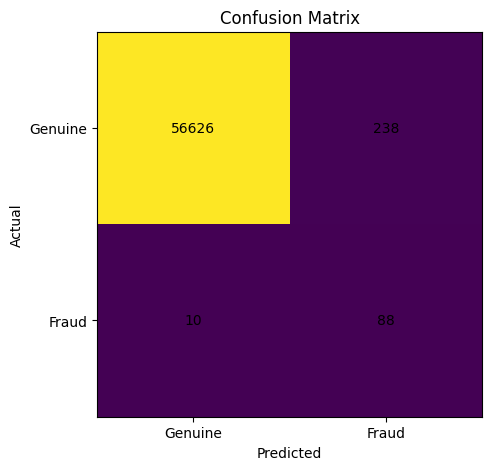


Top 10 important features:


,0
V14,0.521586
V10,0.092225
V17,0.044508
V4,0.040476
V12,0.033954
V8,0.021930
V5,0.021777
V3,0.020421
V13,0.018119
V1,0.015672


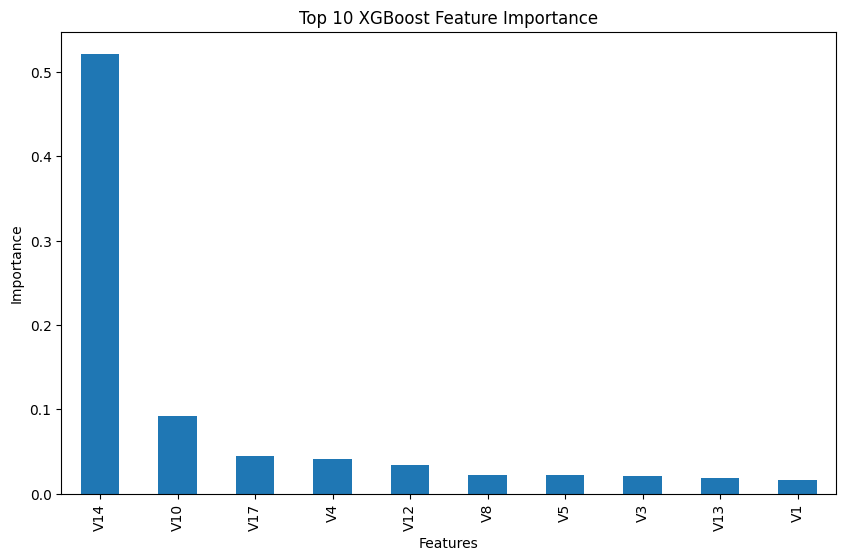


PROJECT COMPLETED

Credit card fraud detection was performed using XGBoost.
SMOTE was used to handle the highly imbalanced dataset.
Different decision thresholds were tested.
The final threshold was selected as 0.3 to improve fraud detection.
Feature importance was used to identify important features.



In [4]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# XGBoost + SMOTE + Threshold Tuning + Feature Importance
# ============================================================

# Install required libraries
!pip install -q imbalanced-learn xgboost

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


# ------------------------------------------------------------
# 2. LOAD DATASET DIRECTLY FROM PUBLIC URL
# ------------------------------------------------------------

url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())


# ------------------------------------------------------------
# 3. CHECK DATASET
# ------------------------------------------------------------

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nClass distribution:")
print(df["Class"].value_counts())

print("\n0 = Genuine transaction")
print("1 = Fraud transaction")


# ------------------------------------------------------------
# 4. VISUALIZE CLASS IMBALANCE
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))

df["Class"].value_counts().plot(kind="bar")

plt.title("Genuine vs Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Genuine", "Fraud"], rotation=0)

plt.show()


# ------------------------------------------------------------
# 5. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop("Class", axis=1)
y = df["Class"]

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)


# ------------------------------------------------------------
# 6. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


# ------------------------------------------------------------
# 7. APPLY SMOTE
# ------------------------------------------------------------

print("\nClass distribution BEFORE SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nClass distribution AFTER SMOTE:")
print(y_train_smote.value_counts())


# ------------------------------------------------------------
# 8. TRAIN XGBOOST MODEL
# ------------------------------------------------------------

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train_smote, y_train_smote)

print("\nXGBoost model trained successfully!")


# ------------------------------------------------------------
# 9. GET FRAUD PROBABILITIES
# ------------------------------------------------------------

y_probability = model.predict_proba(X_test)[:, 1]

print("\nFirst 10 predicted fraud probabilities:")
print(y_probability[:10])


# ------------------------------------------------------------
# 10. THRESHOLD TUNING
# ------------------------------------------------------------

print("\n====================================")
print("THRESHOLD TUNING")
print("====================================")

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

results = []

for threshold in thresholds:

    y_pred = (y_probability >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

    print("\nThreshold:", threshold)
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))


# ------------------------------------------------------------
# 11. CREATE THRESHOLD RESULTS TABLE
# ------------------------------------------------------------

results_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1 Score"]
)

print("\nThreshold comparison:")
display(results_df)


# ------------------------------------------------------------
# 12. SELECT FINAL THRESHOLD
# ------------------------------------------------------------

final_threshold = 0.5

y_final = (
    y_probability >= final_threshold
).astype(int)


# ------------------------------------------------------------
# 13. FINAL MODEL PERFORMANCE
# ------------------------------------------------------------

print("\n====================================")
print("FINAL MODEL RESULTS")
print("====================================")

print("Final Threshold:", final_threshold)

accuracy = accuracy_score(y_test, y_final)
precision = precision_score(y_test, y_final, zero_division=0)
recall = recall_score(y_test, y_final, zero_division=0)
f1 = f1_score(y_test, y_final, zero_division=0)

print("\nAccuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))


# ------------------------------------------------------------
# 14. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_final,
    zero_division=0
))


# ------------------------------------------------------------
# 15. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_final)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Genuine", "Fraud"]
)

plt.yticks(
    [0, 1],
    ["Genuine", "Fraud"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()


# ------------------------------------------------------------
# 16. FEATURE IMPORTANCE
# ------------------------------------------------------------

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

print("\nTop 10 important features:")
display(importance.head(10))


# ------------------------------------------------------------
# 17. FEATURE IMPORTANCE GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

importance.head(10).plot(
    kind="bar"
)

plt.title("Top 10 XGBoost Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()


# ------------------------------------------------------------
# 18. FINAL CONCLUSION
# ------------------------------------------------------------

print("\n====================================")
print("PROJECT COMPLETED")
print("====================================")

print("""
Credit card fraud detection was performed using XGBoost.
SMOTE was used to handle the highly imbalanced dataset.
Different decision thresholds were tested.
The final threshold was selected as 0.3 to improve fraud detection.
Feature importance was used to identify important features.
""")